# 02 — Klassifikation

Q1-2024-Performance (Total Return), Zuordnung zu **Winners / Losers / Steady** per Perzentil-Schwellen (`src.classifier`) und Visualisierung der Verteilung sowie der Gruppen.

**Voraussetzung:** OHLCV-Cache wie in Notebook 01 (oder erster Lauf lädt von Yahoo).

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.classifier import (
    assign_groups,
    classification_quality,
    compute_q1_returns,
    plot_group_characteristics,
    plot_return_distribution,
)
from src.data_loader import download_ohlcv
from src.universe import filter_by_min_volume, get_spi_extra_tickers

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

## OHLCV laden

Gleiche Pipeline wie Notebook 01: Universum, optional `TICKER_LIMIT` für Tests, Parquet-Cache, dann Liquiditätsfilter gemäß `config.MIN_DAILY_VOLUME_CHF`.

In [2]:
# None = alle SPI-Extra-Ticker; z. B. 30 für einen schnellen Smoke-Test
TICKER_LIMIT: int | None = None

all_tickers = get_spi_extra_tickers()
tickers = all_tickers if TICKER_LIMIT is None else all_tickers[:TICKER_LIMIT]

cache_dir = config.ensure_data_dir()
FORCE_REFRESH = False

ohlcv_by_ticker = download_ohlcv(
    tickers,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=cache_dir,
    force_refresh=FORCE_REFRESH,
    max_workers=8,
    retries=2,
)

if not ohlcv_by_ticker:
    raise RuntimeError(
        "Keine OHLCV-Daten — Netzwerk prüfen oder Notebook 01 einmal ausführen."
    )

liquid_tickers = filter_by_min_volume(ohlcv_by_ticker, config.MIN_DAILY_VOLUME_CHF)
ohlcv_liquid = {t: ohlcv_by_ticker[t] for t in liquid_tickers if t in ohlcv_by_ticker}

if not ohlcv_liquid:
    warnings.warn(
        "Keine Ticker nach Liquiditätsfilter — es werden alle geladenen Serien verwendet.",
        stacklevel=1,
    )
    ohlcv_liquid = ohlcv_by_ticker

print(f"Projekt: {PROJECT_ROOT}")
print(f"Klassifikationsfenster: {config.CLASS_Q_START} … {config.CLASS_Q_END}")
print(
    f"OHLCV: {len(ohlcv_by_ticker)} Ticker, "
    f"{len(ohlcv_liquid)} nach Liquiditätsfilter für Q1-Analyse"
)

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Fail

Projekt: /Users/stephangath/cursorAi/Stock Analysis AI
Klassifikationsfenster: 2024-01-02 … 2024-03-31
OHLCV: 154 Ticker, 136 nach Liquiditätsfilter für Q1-Analyse


## Q1 2024 Total Return und Gruppen

`compute_q1_returns` bildet \((\text{Close}_{\text{End}} / \text{Close}_{\text{Start}}) - 1\) im Fenster aus `config`. `assign_groups` mit `method="percentile"` entspricht Top-/Bottom-Viertel (Konfiguration `WINNER_PERCENTILE` / `LOSER_PERCENTILE`).

In [3]:
q1_returns = compute_q1_returns(
    ohlcv_liquid,
    q_start=config.CLASS_Q_START,
    q_end=config.CLASS_Q_END,
)
labels = assign_groups(q1_returns, method="percentile")
quality = classification_quality(q1_returns, labels)

valid = q1_returns.dropna()
print(f"Gültige Q1-Returns: {len(valid)} / {len(q1_returns)}")
print(f"Silhouette: {quality.get('silhouette')!r}, Balance-Score: {quality.get('balance_score', 0):.4f}")
print("Zähler je Gruppe:", quality.get("counts", {}))

summary_df = pd.DataFrame({"q1_return": q1_returns, "group": labels}).dropna()
summary_df = summary_df.sort_values("q1_return", ascending=False)
summary_df.head(8)

Gültige Q1-Returns: 135 / 136
Silhouette: 0.49510260867197076, Balance-Score: 0.0513
Zähler je Gruppe: {'Steady': 67, 'Losers': 34, 'Winners': 34}


,q1_return,group
NWRN.SW,0.698031,Winners
KURN.SW,0.561856,Winners
RIEN.SW,0.468468,Winners
KUD.SW,0.410714,Winners
BANB.SW,0.386838,Winners
IDIA.SW,0.360924,Winners
WIHN.SW,0.338006,Winners
SUN.SW,0.317718,Winners


## Visualisierung

Histogramm der Returns (`plot_return_distribution`) und Boxplots je Gruppe (`plot_group_characteristics`).

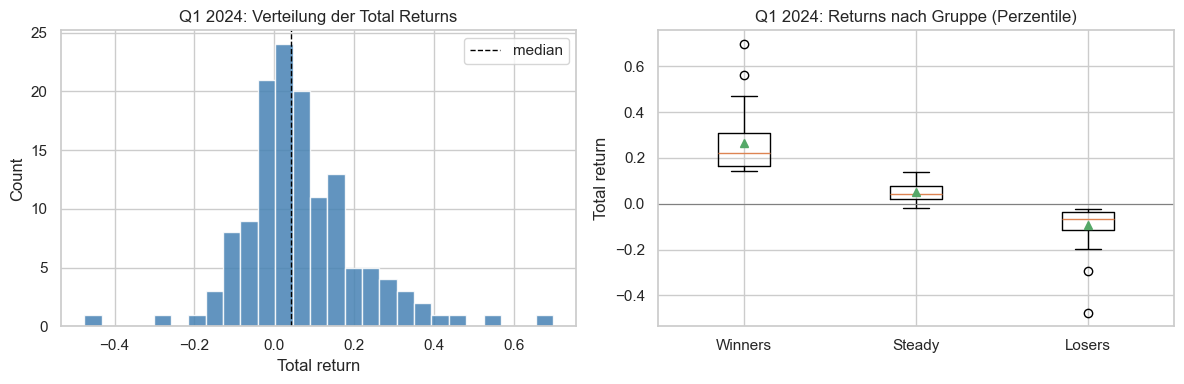

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_return_distribution(
    q1_returns,
    title="Q1 2024: Verteilung der Total Returns",
    ax=axes[0],
)
plot_group_characteristics(
    q1_returns,
    labels,
    title="Q1 2024: Returns nach Gruppe (Perzentile)",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

In [5]:
# untere Performer (Losers)
summary_df.tail(8)

,q1_return,group
METN.SW,-0.120000,Losers
LEHN.SW,-0.124230,Losers
KNIN.SW,-0.147997,Losers
SENS.SW,-0.157828,Losers
CLTN.SW,-0.170029,Losers
LEON.SW,-0.196455,Losers
GAM.SW,-0.295148,Losers
AMS.SW,-0.476250,Losers
